In [1]:
import pandas as pd
import numpy as np  
import xgboost as xgb
import optuna
from optuna_integration import XGBoostPruningCallback
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import shap
from dotenv import load_dotenv
import os
import joblib
from pathlib import Path

# Establish Country & Pollutant

In [2]:
load_dotenv()

True

In [3]:
POLLUTANT = "SO2"

In [4]:
COUNTRY_CODE = os.getenv("COUNTRY_CODE")   
RESULTS_SAVE_FOLDER = os.getenv("RESULTS_SAVE_FOLDER")

In [5]:
# reading in data
base_path = os.getenv("BASE_DATA_PATH")
file_name = f"{COUNTRY_CODE}_{POLLUTANT}_Daily_Cleaned.parquet"
file_path = os.path.join(base_path, file_name)

In [6]:
# saving results
RUN_ID = f"{COUNTRY_CODE}_{POLLUTANT}"

output_dir = Path(RESULTS_SAVE_FOLDER) / f"Results_{RUN_ID}"
output_dir.mkdir(parents=True, exist_ok=True)

In [7]:
# saving model
model_filename = output_dir / f"xgboost_model_{COUNTRY_CODE}_{POLLUTANT}.pkl"

In [8]:
def log_stat(name, value): # save statistics as a test file
    with open(output_dir / "data_processing_log.txt", "a") as f:
        f.write(f"{name}: {value}\n")

with open(output_dir / "data_processing_log.txt", "w") as f: # clear log if it exists to start fresh
    f.write(f"Processing Log for {RUN_ID}\n")

In [9]:
df = pd.read_parquet(file_path, engine = 'pyarrow')

In [10]:
df.head(10)

,Samplingpoint,Start,Value
0,AL/SPO-AL0201A_00001_100,2013-01-01,NaN
1,AL/SPO-AL0201A_00001_100,2013-01-02,NaN
2,AL/SPO-AL0201A_00001_100,2013-01-03,NaN
3,AL/SPO-AL0201A_00001_100,2013-01-04,NaN
4,AL/SPO-AL0201A_00001_100,2013-01-05,NaN
5,AL/SPO-AL0201A_00001_100,2013-01-06,NaN
6,AL/SPO-AL0201A_00001_100,2013-01-07,NaN
7,AL/SPO-AL0201A_00001_100,2013-01-08,NaN
8,AL/SPO-AL0201A_00001_100,2013-01-09,NaN
9,AL/SPO-AL0201A_00001_100,2013-01-10,NaN


# Machine Learning Preperation - Feature Extraction & Dropping NaN

In [11]:
df['Start'] = pd.to_datetime(df['Start']) 
df = df.sort_values(by=['Samplingpoint', 'Start']).reset_index(drop=True) # sorting by station and start(date) and resetting index

df['Samplingpoint'] = df['Samplingpoint'].astype('category') # set as a category to use as category feature (can avpid using pd.getdummies onehotencoding and creating more columns), faster processing and less memory usage

In [12]:
# Extracting time based features
df['DayOfWeek'] = df['Start'].dt.dayofweek
df['Month'] = df['Start'].dt.month
df['DayOfYear'] = df['Start'].dt.dayofyear
df['IsWeekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)

In [13]:
df['Lag_1'] = df.groupby('Samplingpoint')['Value'].shift(1) 
df['Lag_7'] = df.groupby('Samplingpoint')['Value'].shift(7) 

In [14]:
df = df.set_index('Start') # Need index to be the 'Start'(date) column for rolling with time-based windows to work properly

df['Rolling_Mean_7D'] = df.groupby('Samplingpoint')['Value'].transform(
    lambda x: x.rolling('7D', min_periods=4).mean() # 7d creates rolling window of 7 calendar days instead of last 7 rows
)
df = df.reset_index()

In [15]:
df['Target'] = df.groupby('Samplingpoint')['Value'].shift(-1) # Target (y), shfts value back by 1 on the indexlevel, to get the next day today

In [16]:
print(f"Data shape after Feature Engineering {df.shape}")
df.head(10)

Data shape after Feature Engineering (17971, 11)


,Start,Samplingpoint,Value,DayOfWeek,Month,DayOfYear,IsWeekend,Lag_1,Lag_7,Rolling_Mean_7D,Target
0,2013-01-01,AL/SPO-AL0201A_00001_100,NaN,1,1,1,0,NaN,NaN,NaN,NaN
1,2013-01-02,AL/SPO-AL0201A_00001_100,NaN,2,1,2,0,NaN,NaN,NaN,NaN
2,2013-01-03,AL/SPO-AL0201A_00001_100,NaN,3,1,3,0,NaN,NaN,NaN,NaN
3,2013-01-04,AL/SPO-AL0201A_00001_100,NaN,4,1,4,0,NaN,NaN,NaN,NaN
4,2013-01-05,AL/SPO-AL0201A_00001_100,NaN,5,1,5,1,NaN,NaN,NaN,NaN
5,2013-01-06,AL/SPO-AL0201A_00001_100,NaN,6,1,6,1,NaN,NaN,NaN,NaN
6,2013-01-07,AL/SPO-AL0201A_00001_100,NaN,0,1,7,0,NaN,NaN,NaN,NaN
7,2013-01-08,AL/SPO-AL0201A_00001_100,NaN,1,1,8,0,NaN,NaN,NaN,NaN
8,2013-01-09,AL/SPO-AL0201A_00001_100,NaN,2,1,9,0,NaN,NaN,NaN,NaN
9,2013-01-10,AL/SPO-AL0201A_00001_100,NaN,3,1,10,0,NaN,NaN,NaN,NaN


In [17]:
df_ml_ready = df.dropna(subset=['Target']).reset_index(drop=True) # drop Nan target but keep the featues with xgboost
display(df_ml_ready.head(10))
df_ml_ready.isna().sum()

,Start,Samplingpoint,Value,DayOfWeek,Month,DayOfYear,IsWeekend,Lag_1,Lag_7,Rolling_Mean_7D,Target
0,2013-03-31,AL/SPO-AL0201A_00001_100,NaN,6,3,90,1,NaN,NaN,NaN,9.029167
1,2013-04-01,AL/SPO-AL0201A_00001_100,9.029167,0,4,91,0,NaN,NaN,NaN,8.246667
2,2013-04-02,AL/SPO-AL0201A_00001_100,8.246667,1,4,92,0,9.029167,NaN,NaN,8.196667
3,2013-04-03,AL/SPO-AL0201A_00001_100,8.196667,2,4,93,0,8.246667,NaN,NaN,8.719167
4,2013-04-04,AL/SPO-AL0201A_00001_100,8.719167,3,4,94,0,8.196667,NaN,8.547917,8.681250
5,2013-04-05,AL/SPO-AL0201A_00001_100,8.681250,4,4,95,0,8.719167,NaN,8.574583,7.989167
6,2013-04-06,AL/SPO-AL0201A_00001_100,7.989167,5,4,96,1,8.681250,NaN,8.477014,9.384167
7,2013-04-07,AL/SPO-AL0201A_00001_100,9.384167,6,4,97,1,7.989167,NaN,8.606607,8.127917
8,2013-04-08,AL/SPO-AL0201A_00001_100,8.127917,0,4,98,0,9.384167,9.029167,8.477857,7.774412
9,2013-04-09,AL/SPO-AL0201A_00001_100,7.774412,1,4,99,0,8.127917,8.246667,8.410392,7.420907


Start                0
Samplingpoint        0
Value              132
DayOfWeek            0
Month                0
DayOfYear            0
IsWeekend            0
Lag_1              247
Lag_7              737
Rolling_Mean_7D    398
Target               0
dtype: int64

# Machine Learning

In [18]:
features = ['Samplingpoint', 'Value', 'DayOfWeek', 'Month', 'DayOfYear', 'IsWeekend', 'Lag_1', 'Lag_7', 'Rolling_Mean_7D']

In [19]:
train_data = df_ml_ready[(df_ml_ready['Start'] >= '2013-01-01') & (df_ml_ready['Start'] <= '2020-12-31')]
val_data = df_ml_ready[(df_ml_ready['Start'] >= '2021-01-01') & (df_ml_ready['Start'] <= '2022-12-31')]
test_data = df_ml_ready[(df_ml_ready['Start'] >= '2023-01-01') & (df_ml_ready['Start'] <= '2024-12-31')]

# Sort purely by date so TimeSeriesSplit moves properly through time, no longer need to sort by station anymore
train_data = train_data.sort_values(by='Start').reset_index(drop=True)
val_data = val_data.sort_values(by='Start').reset_index(drop=True)
test_data = test_data.sort_values(by='Start').reset_index(drop=True)

X_train, y_train = train_data[features], train_data['Target']
X_val, y_val = val_data[features], val_data['Target']
X_test, y_test = test_data[features], test_data['Target']

print(f"Train shape: {X_train.shape}, Val shape: {X_val.shape}, Test shape: {X_test.shape}")

Train shape: (5709, 9), Val shape: (41, 9), Test shape: (1915, 9)


In [20]:
# save features 
feature_names = list(X_train.columns)
features_filename = output_dir / f"xgboost_features_{COUNTRY_CODE}_{POLLUTANT}.pkl"
joblib.dump(feature_names, features_filename)

['C:\\Users\\keith\\OneDrive\\Documents\\DataWranglingwithEuropeanAirQualityData\\Source_Task7_Demo\\SavedResults\\Results_AL_SO2\\xgboost_features_AL_SO2.pkl']

In [21]:
def objective(trial):
    # Hyperparameeter search space
    params = {
        'objective': 'reg:squarederror',
        'tree_method': 'hist', # faster for cpu 
        # 'tree_method' : 'exact', # more accurate but slower
        'n_estimators': trial.suggest_int('n_estimators', 100, 1200),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10), # prevent overfitting
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10, log=True)  
    }
    
    tscv = TimeSeriesSplit(n_splits=5) # Time Series Cross Validation Split (5 splits/folds)
    cv_scores = []
    
    for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train)):

        X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]


        model = xgb.XGBRegressor(
            **params, 
            enable_categorical=True, # for the samplingpoint categorical
            early_stopping_rounds=30,
            random_state=42 # for reproducatbility
        )
        
        model.fit(
            X_fold_train, y_fold_train, 
            eval_set=[(X_fold_val, y_fold_val)],  # validation data for early stopping
            verbose=False, 
        )

        preds = model.predict(X_fold_val)
        rmse = np.sqrt(mean_squared_error(y_fold_val, preds))
        cv_scores.append(rmse)

        # Report the RMSE for this fold to Optuna for pruning decisions
        trial.report(rmse, step=fold_idx)

        # Handle pruning based on the fold's performance
        if trial.should_prune():
            raise optuna.TrialPruned()
        

    weights = np.arange(1, len(cv_scores) + 1) # more recent folds get higher weight, as there will be more data to train on and gives better representation of recenncy
    return np.average(cv_scores, weights=weights)


In [22]:
# Bayesian Hyperparameter Optimisation using Optuna
study = optuna.create_study(direction='minimize', pruner=optuna.pruners.MedianPruner(n_warmup_steps=2)) # minimise rmse and use median pruner to stop bad trials early based on median of intermediate results
study.optimize(objective, n_trials=200) 
print(f"Best trial parameters: {study.best_params}")

[I 2026-03-12 16:30:17,593] A new study created in memory with name: no-name-1b1d20df-ac6c-479a-952e-24eae32792ca
[I 2026-03-12 16:30:22,074] Trial 0 finished with value: 1.9264680368751441 and parameters: {'n_estimators': 900, 'learning_rate': 0.015612464126119231, 'max_depth': 11, 'subsample': 0.8241264784418523, 'colsample_bytree': 0.8741190604794761, 'min_child_weight': 6, 'gamma': 4.837854363028465, 'reg_lambda': 0.04982966228900178}. Best is trial 0 with value: 1.9264680368751441.
[I 2026-03-12 16:30:27,484] Trial 1 finished with value: 1.9162534931106203 and parameters: {'n_estimators': 1021, 'learning_rate': 0.007562319092645666, 'max_depth': 11, 'subsample': 0.9022285137583952, 'colsample_bytree': 0.9315275410309583, 'min_child_weight': 8, 'gamma': 4.580950985672646, 'reg_lambda': 0.5865893112388477}. Best is trial 1 with value: 1.9162534931106203.
[I 2026-03-12 16:30:30,288] Trial 2 finished with value: 1.8949173710173925 and parameters: {'n_estimators': 530, 'learning_rate':

Best trial parameters: {'n_estimators': 642, 'learning_rate': 0.022656011499361837, 'max_depth': 4, 'subsample': 0.7614165022348566, 'colsample_bytree': 0.7135929843445971, 'min_child_weight': 5, 'gamma': 2.2891918814077163, 'reg_lambda': 5.653322910047407}


In [23]:
# Incorporation the validating set into train set after opitmal hyperparameters found

# Use X_val purely to find the optimal stopping point
temp_model = xgb.XGBRegressor(
    **study.best_params,
    objective='reg:squarederror', 
    enable_categorical=True,
    tree_method = 'hist', 
    early_stopping_rounds=30,
    random_state=42
    
)

temp_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# Get the exact number of trees where it peaked
optimal_trees = temp_model.best_iteration + 1  # best_iteration is zero-indexed, so add 1 to get the actual number of trees

# Make a copy of the best parameters and overwrite with best trees so it works in the best (final) model
final_params = study.best_params.copy()
final_params['n_estimators'] = optimal_trees

X_train_full = pd.concat([X_train, X_val]) # concat train and val sets to retrain final model on all data up to 2022m(recent trends)
y_train_full = pd.concat([y_train, y_val])


# Retrain with our final (best) hyperparams with new trian data
best_model = xgb.XGBRegressor(
    **final_params,
    objective='reg:squarederror',
    tree_method='hist', 
    enable_categorical=True,
    random_state=42
)


best_model.fit(X_train_full, y_train_full, verbose=100)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7135929843445971
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import 

In [24]:
# saving best model
joblib.dump(best_model, model_filename)

['C:\\Users\\keith\\OneDrive\\Documents\\DataWranglingwithEuropeanAirQualityData\\Source_Task7_Demo\\SavedResults\\Results_AL_SO2\\xgboost_model_AL_SO2.pkl']

In [25]:
# Predit on the Test Set
test_preds = best_model.predict(X_test)

# Results & Evaluation

In [26]:
# Evaluate Model
rmse = np.sqrt(mean_squared_error(y_test, test_preds))
mae = mean_absolute_error(y_test, test_preds)
r2 = r2_score(y_test, test_preds)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R2:   {r2:.4f}")

RMSE: 1.7833
MAE:  0.8622
R2:   0.6441


In [27]:
log_stat(f"{POLLUTANT} RMSE: ", rmse)
log_stat(f"{POLLUTANT} MAE: ",  mae)
log_stat(f"{POLLUTANT} R2: ",   r2)

In [28]:
# For Comparrison a naive non ML just guessing that tomorrow's pollutant will be the same as today
naive_preds = X_test['Value'].dropna()

# if you want the RMSE you must compare against the same rows of y_test
naive_rmse = np.sqrt(
    mean_squared_error(y_test.loc[naive_preds.index], naive_preds)
)

print(f"XGBoost RMSE: {rmse:.4f}")
print(f"Naive Baseline RMSE: {naive_rmse:.4f}")

XGBoost RMSE: 1.7833
Naive Baseline RMSE: 1.8729


In [29]:
log_stat(f"{POLLUTANT}Naive Baseline RMSE: ", naive_rmse)

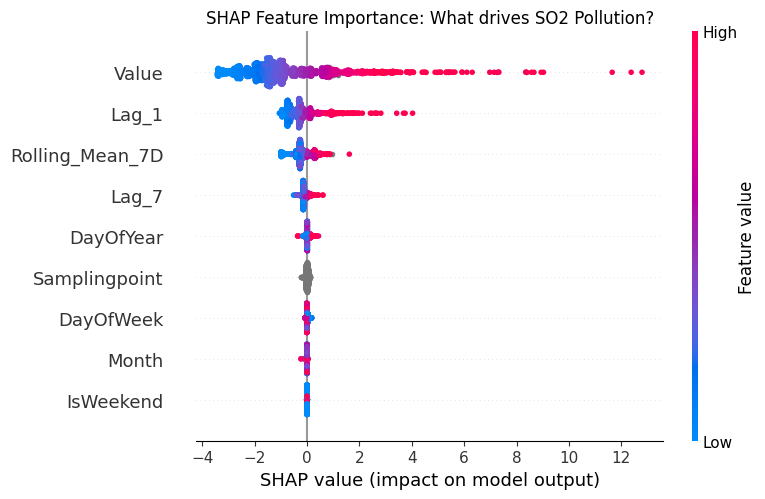

In [30]:
# Initialize the SHAP Explainer using your trained XGBoost model
explainer = shap.TreeExplainer(best_model) # For XGBoost use TreeExplaienr

shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, plot_type="dot", show=False)
plt.title(f"SHAP Feature Importance: What drives {POLLUTANT} Pollution?")
plt.tight_layout()
plt.savefig(output_dir / f"{RUN_ID}_SHAP_Feature_importance.png", bbox_inches='tight')
plt.show()

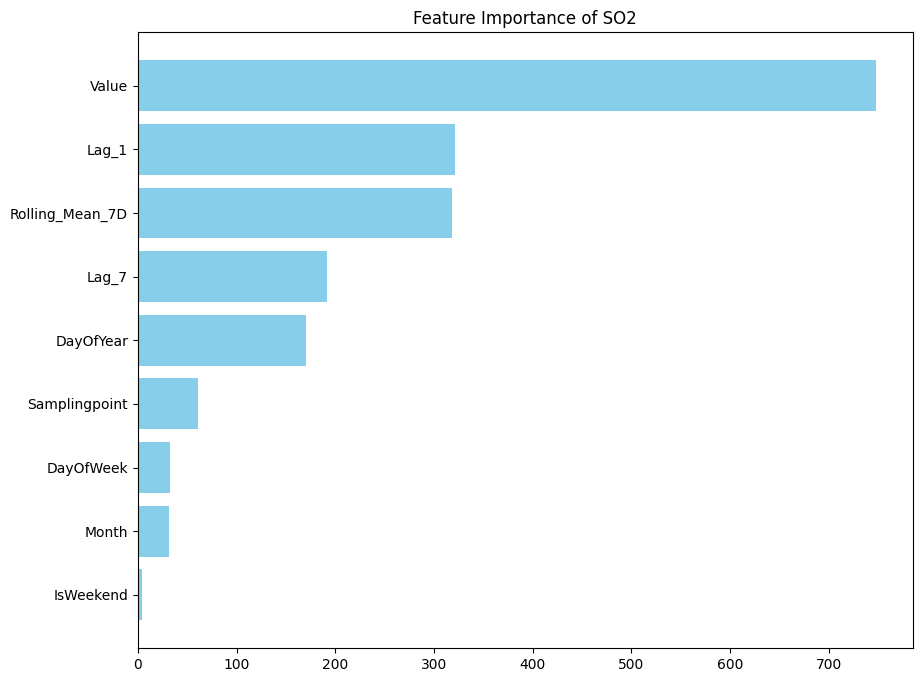

In [31]:
importance = best_model.get_booster().get_score(importance_type='weight')

importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values(by='Importance', ascending=False)


top_n = 20
plt.figure(figsize=(10, 8))
plt.title(f"Feature Importance of {POLLUTANT}")
plt.barh(
    importance_df['Feature'].head(top_n)[::-1],
    importance_df['Importance'].head(top_n)[::-1],
    color='skyblue'
)
plt.savefig(output_dir / f"{RUN_ID}_Feature_Importance.png", bbox_inches='tight')

RMSE: 1.7833
MAE:  0.8622
R2:   0.6441
Samplingpoint AL/SPO-AL0208A_00001_100 -> RMSE: 3.53 | MAE: 2.03 | R2: 0.38


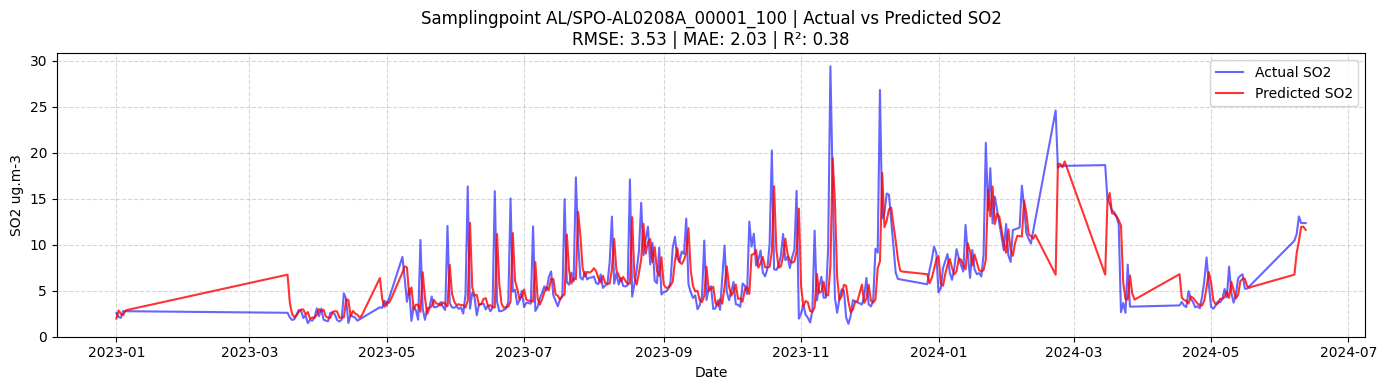

Samplingpoint AL/SPO-AL0207A_00001_100 -> RMSE: 0.72 | MAE: 0.44 | R2: 0.77


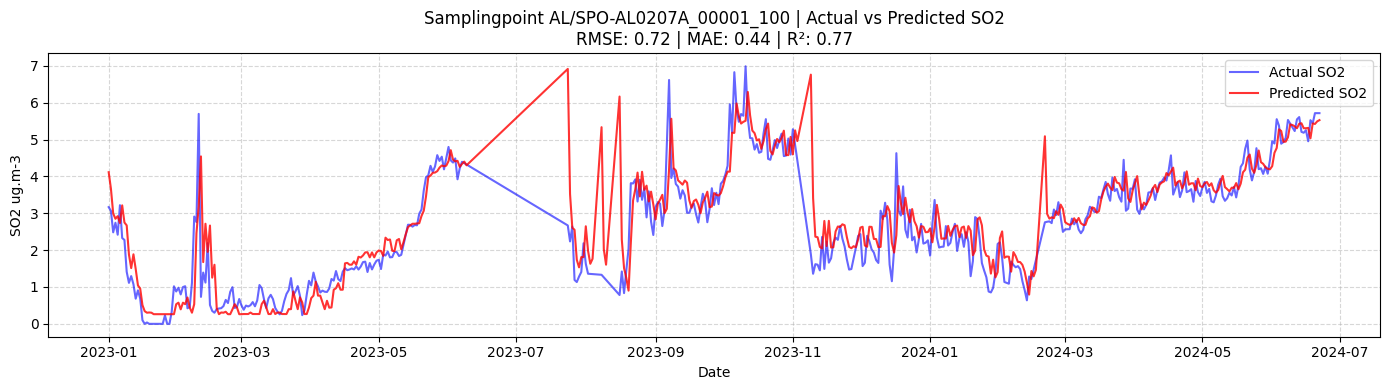

Samplingpoint AL/SPO-AL0205A_00001_100 -> RMSE: 0.99 | MAE: 0.67 | R2: 0.86


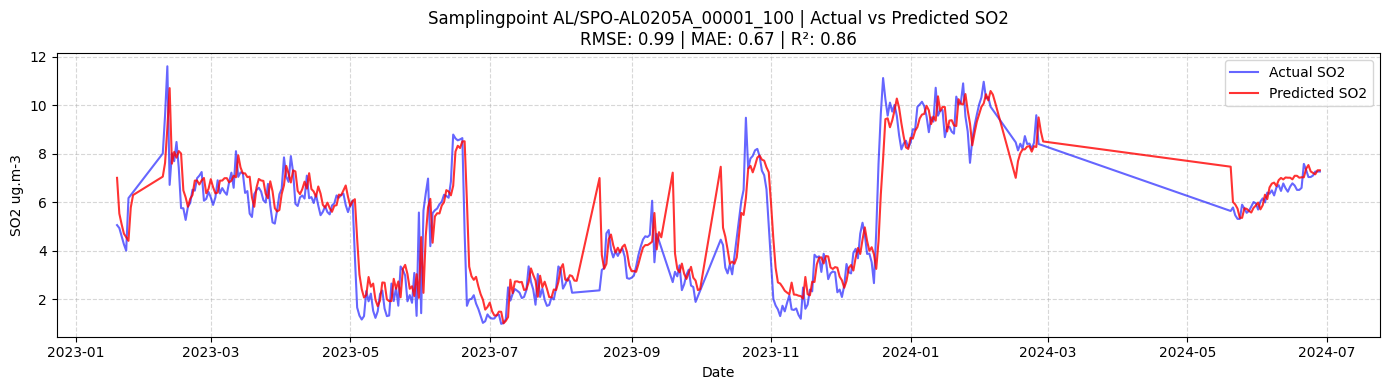

Samplingpoint AL/SPO-AL0203A_00001_100 -> RMSE: 0.68 | MAE: 0.48 | R2: 0.58


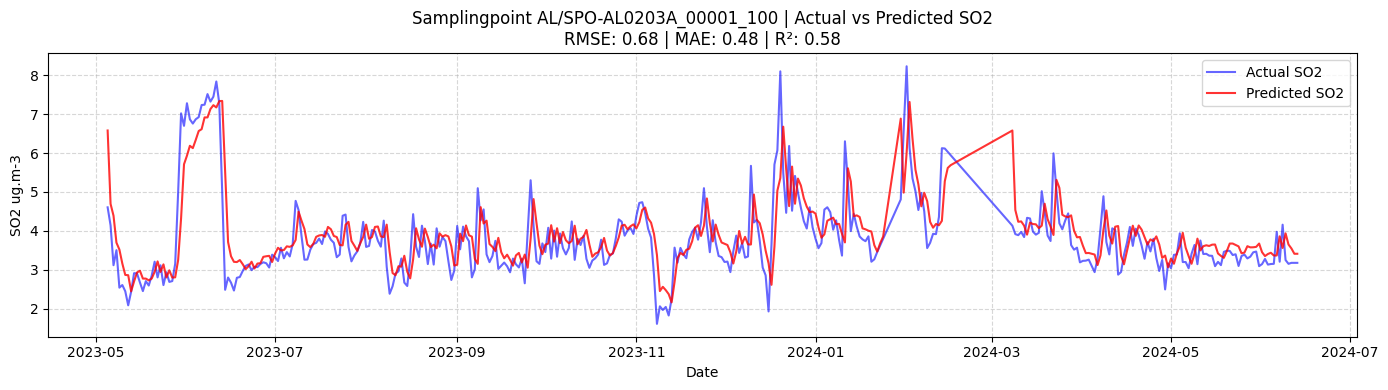

Samplingpoint AL/SPO-AL0206A_00001_100 -> RMSE: 1.47 | MAE: 0.83 | R2: 0.58


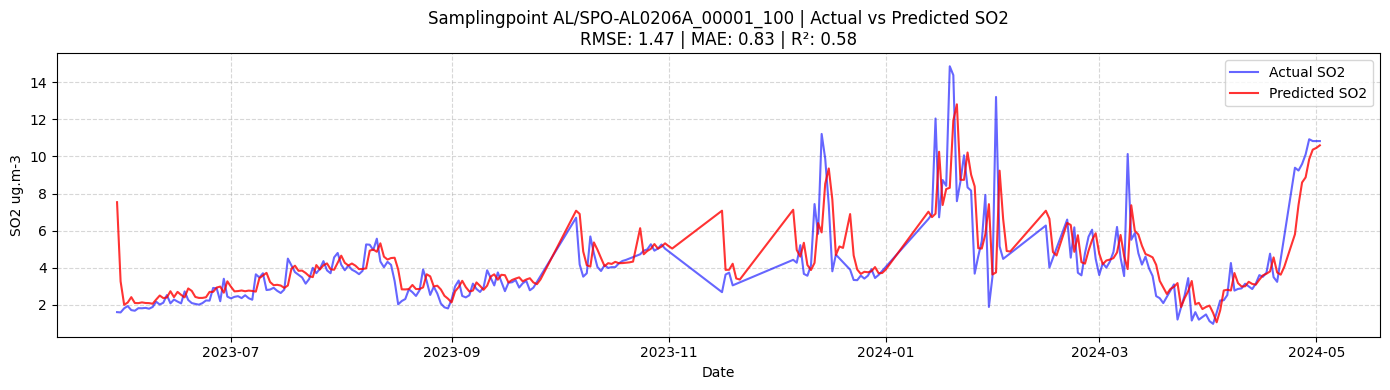

In [32]:
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R2:   {r2:.4f}")


# folder for these prediction plots
pred_plot_dir = output_dir / "Predict_vs_Actual_Plots"
pred_plot_dir.mkdir(parents=True, exist_ok=True)

# Plotting Actual vs Predicted for each station in the Test Set
results_df = test_data.copy() # already grouped staion and start (date)
results_df['Actual'] = y_test
results_df['Predicted'] = test_preds


stations = results_df['Samplingpoint'].unique() 

station_metrics_list = [] 

for station in stations:
    station_data = results_df[results_df['Samplingpoint'] == station] 
    
    # skip stations with not enough data to calculate R2 for the stations that have shut down/little test data
    if len(station_data) < 2:
        continue
        
    st_rmse = np.sqrt(mean_squared_error(station_data['Actual'], station_data['Predicted']))
    st_mae = mean_absolute_error(station_data['Actual'], station_data['Predicted'])
    st_r2 = r2_score(station_data['Actual'], station_data['Predicted'])

    station_metrics_list.append({ # add evalutation to list
        'Station': station,
        'RMSE': round(st_rmse, 3),
        'MAE': round(st_mae, 3),
        'R2': round(st_r2, 3)
    })
    
    print(f"Samplingpoint {station} -> RMSE: {st_rmse:.2f} | MAE: {st_mae:.2f} | R2: {st_r2:.2f}")
    

    plt.figure(figsize=(14, 4))
    
    # Using 'Start' for the x-axis datetime timeline
    plt.plot(station_data['Start'], station_data['Actual'], label=f'Actual {POLLUTANT}', color='blue', alpha=0.6)
    plt.plot(station_data['Start'], station_data['Predicted'], label=f'Predicted {POLLUTANT}', color='red', alpha=0.8, linewidth=1.5)
    
    plt.title(f'Samplingpoint {station} | Actual vs Predicted {POLLUTANT}\nRMSE: {st_rmse:.2f} | MAE: {st_mae:.2f} | R²: {st_r2:.2f}')
    plt.xlabel('Date')
    plt.ylabel(f'{POLLUTANT} ug.m-3')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()

    clean_station_name = str(station).replace(".", "_").replace("/", "_")
    file_name = f"{COUNTRY_CODE}_{POLLUTANT}_{clean_station_name}_predict.png"
    plt.savefig(pred_plot_dir / file_name, dpi=150)

    plt.show()
    plt.close()


# list to df to csv
metrics_df = pd.DataFrame(station_metrics_list)
csv_filename = output_dir / f"{COUNTRY_CODE}_{POLLUTANT}_Every_Station_Metrics.csv"
metrics_df.to_csv(csv_filename, index=False)